In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
preprocessed_df=pd.read_csv('UKBB_preprocessed.csv')
preprocessed_df.head()

,Broad_ID,gene1,gene2,gene3,VAF1,VAF2,VAF3,sex,CH_score,eid,...,MRV,MspCV,immret,hiscatret,age,year_of_assessment,year_MN,MN_type,CHRS,MN
0,3463778,NaN,NaN,NaN,NaN,NaN,NaN,1,0.0,4726860.0,...,111.23,82.09,0.211,0.014,42.000000,2009.666667,NaN,NaN,0.0,0
1,2821197,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,1633945.0,...,104.46,81.47,0.214,0.009,47.000000,2009.666667,NaN,NaN,0.0,0
2,1514525,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,4596360.0,...,106.56,86.68,0.228,0.005,52.416667,2009.666667,NaN,NaN,0.0,0
3,2491905,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,3143018.0,...,111.75,83.24,0.360,0.030,65.750000,2009.666667,NaN,NaN,0.0,0
4,3250377,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,2254568.0,...,107.37,82.90,0.271,0.021,57.000000,2009.666667,NaN,NaN,0.0,0


In [29]:
preprocessed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 461576 entries, 0 to 461575
Data columns (total 39 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Broad_ID            461576 non-null  int64  
 1   gene1               29113 non-null   object 
 2   gene2               1987 non-null    object 
 3   gene3               202 non-null     object 
 4   VAF1                29113 non-null   float64
 5   VAF2                1987 non-null    float64
 6   VAF3                202 non-null     float64
 7   sex                 461576 non-null  int64  
 8   CH_score            461576 non-null  float64
 9   eid                 461576 non-null  float64
 10  WBC                 461576 non-null  float64
 11  RBC                 461576 non-null  float64
 12  Hbconc              461576 non-null  float64
 13  haematocrit         461576 non-null  float64
 14  MCV                 461576 non-null  float64
 15  MCHb                461576 non-nul

In [30]:
#followup time
last_year=2022.0
followuptime=last_year-preprocessed_df['year_of_assessment']
followuptime.min(),followuptime.max(),followuptime.median()

(11.166666666666742, 15.0, 12.916666666666742)

In [31]:
# How many participants had CH?
tot=len(preprocessed_df)
CH=len(preprocessed_df[preprocessed_df['CHRS']>0])
MN=len(preprocessed_df[preprocessed_df['MN']==1])
CHMN = len(preprocessed_df[(preprocessed_df['CHRS']>0)&(preprocessed_df['MN']==1)])

print("Total number of participants, after exclusions:",tot)
print("Number of participants with CH:", CH, np.round((CH*100/tot),2),"%")
print("Number of participants with MN:", MN, np.round((MN*100/tot),2),"%")
print("Number of participants with CH who have MN:", CHMN)

Total number of participants, after exclusions: 461576
Number of participants with CH: 28877 6.26 %
Number of participants with MN: 1652 0.36 %
Number of participants with CH who have MN: 539


## 1. Cytoses and cytopenia and CHIP ##

In [8]:
# CHIP and CCUS based classification

def CCUS(df):
    anemia = ((df['sex'] == 0) & (df['Hbconc'] < 12)) | ((df['sex'] == 1) & (df['Hbconc'] < 13))
    neutropenia = df['neutrophil'] < 1.8
    thrombocytopenia = df['platelet'] < 150

    CH=df['CHRS']>0
    any_condition = anemia | neutropenia | thrombocytopenia
    CCUS = df[CH&any_condition]

    return CCUS

def CHcytoses(df):
    erythro = df['Hbconc'] >= 17
    neutro = df['neutrophil'] >= 6
    thrombo = df['platelet'] >= 450
    mono = df['monocyte'] >= 1
    eosin = df['eosinophil'] >=0.5
    baso=df['basophil']>=0.3
    
    CH=df['CHRS']>0
    any_condition = erythro| neutro| thrombo| mono| eosin| baso
    cytoses = df[CH&any_condition]

    return cytoses


def bothcyto(df):
    anemia = ((df['sex'] == 0) & (df['Hbconc'] < 12)) | ((df['sex'] == 1) & (df['Hbconc'] < 13))
    neutropenia = df['neutrophil'] < 1.8
    thrombocytopenia = df['platelet'] < 150
    erythro = df['Hbconc'] >= 17
    neutro = df['neutrophil'] >= 6
    thrombo = df['platelet'] >= 450
    mono = df['monocyte'] >= 1
    eosin = df['eosinophil'] >=0.5
    baso=df['basophil']>=0.3
    
    CH=df['CHRS']>0
    cytopenia = anemia | neutropenia | thrombocytopenia
    cytoses = erythro|neutro|thrombo|mono|eosin|baso
    both = df[(CH)&(cytopenia)&(cytoses)]

    return both    


def CHIP(df):
    anemia = ((df['sex'] == 0) & (df['Hbconc'] < 12)) | ((df['sex'] == 1) & (df['Hbconc'] < 13))
    neutropenia = df['neutrophil'] < 1.8
    thrombocytopenia = df['platelet'] < 150
    erythro = df['Hbconc'] >= 17
    neutro = df['neutrophil'] >= 6
    thrombo = df['platelet'] >= 450
    mono = df['monocyte'] >= 1
    eosin = df['eosinophil'] >=0.5
    baso=df['basophil']>=0.3

    CH=df['CHRS']>0
    any_condition = anemia | neutropenia | thrombocytopenia | erythro| neutro| thrombo| mono| eosin| baso
    CHIP = df[CH&(~any_condition)]

    return CHIP

def cytopenia(df):
    anemia = ((df['sex'] == 0) & (df['Hbconc'] < 12)) | ((df['sex'] == 1) & (df['Hbconc'] < 13))
    neutropenia = df['neutrophil'] < 1.8
    thrombocytopenia = df['platelet'] < 150

    CH=df['CHRS']>0
    any_condition = anemia | neutropenia | thrombocytopenia
    cytopenia = df[(~CH)&any_condition]

    return cytopenia

def cytoses(df):
    erythro = df['Hbconc'] >= 17
    neutro = df['neutrophil'] >= 6
    thrombo = df['platelet'] >= 450
    mono = df['monocyte'] >= 1
    eosin = df['eosinophil'] >=0.5
    baso=df['basophil']>=0.3
    
    CH=df['CHRS']>0
    any_condition = erythro| neutro| thrombo| mono| eosin| baso
    cytoses = df[(~CH)&(any_condition)]

    return cytoses

def noBD(df):
    anemia = ((df['sex'] == 0) & (df['Hbconc'] < 12)) | ((df['sex'] == 1) & (df['Hbconc'] < 13))
    neutropenia = df['neutrophil'] < 1.8
    thrombocytopenia = df['platelet'] < 150
    erythro = df['Hbconc'] >= 17
    neutro = df['neutrophil'] >= 6
    thrombo = df['platelet'] >= 450
    mono = df['monocyte'] >= 1
    eosin = df['eosinophil'] >=0.5
    baso=df['basophil']>=0.3
    
    CH=df['CHRS']>0
    any_condition = anemia | neutropenia | thrombocytopenia|erythro|neutro|thrombo|mono|eosin|baso
    noBD = df[(~CH)&(~any_condition)]

    return noBD    
    
# Print results
print("Number with CH:",len(preprocessed_df[preprocessed_df['CHRS']>0]))
print("Number with CCUS:", len(CCUS(preprocessed_df)))
print("Number with CHIP:", CHIP(preprocessed_df).shape[0])
print("Number with CHcytoses:", CHcytoses(preprocessed_df).shape[0])
print("Number with cytopenia:", cytopenia(preprocessed_df).shape[0])
print("Number with cytoses:", cytoses(preprocessed_df).shape[0])
print("Number with both cytoses and cytopenia:", bothcyto(preprocessed_df).shape[0])
print("Number with normal blood counts:", noBD(preprocessed_df).shape[0])

Number with CH: 28877
Number with CCUS: 2201
Number with CHIP: 22280
Number with CHcytoses: 4787
Number with cytopenia: 30850
Number with cytoses: 62773
Number with both cytoses and cytopenia: 391
Number with normal blood counts: 343550


## 2. Genetic Data - Molecular CH score, CHRS and MN ##

In [6]:
training_df=pd.read_csv('training_df_3class.csv',usecols=lambda column: column != 'Unnamed: 0')
test_df=pd.read_csv('test_df_3class.csv',usecols=lambda column: column != 'Unnamed: 0')

In [9]:
df_gene=training_df[['gene1','gene2','gene3','VAF1','VAF2','VAF3','sex','CH_score','age','MN','CHRS']]

### 2.1  EDA on molecular CH score  ###

In [8]:
df_gene['CH_score'].value_counts()

CH_score
0.0    346270
3.5     10584
4.0      7236
5.0      2215
4.5      1276
5.5       840
6.0       407
6.5       310
7.5       122
Name: count, dtype: int64

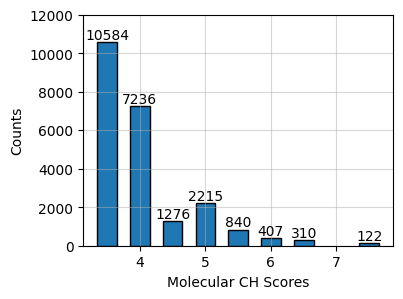

In [10]:
df_sel=df_gene.loc[df_gene['CH_score']>0]
value_counts=df_sel['CH_score'].value_counts()
values=value_counts.index.tolist()
counts=value_counts.values.tolist()
plt.figure(figsize=(4,3))
bars=plt.bar(values,counts,width=0.3, edgecolor='black')
# Add text labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,  # x-position (center of bar)
        height,                           # y-position (top of bar)
        f'{height}',                      # text (can use int(height) too)
        ha='center', va='bottom',         # horizontal and vertical alignment
        fontsize=10, color='black'
    )
plt.grid(True,alpha=0.5)
plt.ylim(0,12000)
plt.xlabel("Molecular CH Scores")
plt.ylabel("Counts")
plt.savefig("figures/MCHhist_training.png", dpi=300, bbox_inches='tight')

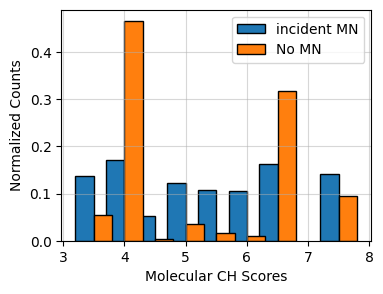

In [11]:
df_sel=df_gene.loc[df_gene['CH_score']>0]
df_sel_MN=df_sel.loc[df_sel['MN']==1]
df_sel_noMN=df_sel.loc[df_sel['MN']==0]
value_counts_mn=df_sel_MN['CH_score'].value_counts()
value_counts_nomn=df_sel_noMN['CH_score'].value_counts()
values_mn=value_counts_mn.index.tolist()
counts_mn=value_counts_mn.values.tolist()
values_nomn=value_counts_nomn.index.tolist()
counts_nomn=value_counts_nomn.values.tolist()
counts_mn_norm = counts_mn / np.array(counts_mn).sum()
counts_nomn_norm = counts_nomn / np.array(counts_nomn).sum()

plt.figure(figsize=(4,3))
width = 0.3

x = np.array(values_mn)

plt.bar(x - width/2, counts_mn_norm, width=width, edgecolor='black', label='incident MN')
plt.bar(x + width/2, counts_nomn_norm, width=width, edgecolor='black', label='No MN')
# Add text labels on top of each bar
'''
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,  # x-position (center of bar)
        height,                           # y-position (top of bar)
        f'{height}',                      # text (can use int(height) too)
        ha='center', va='bottom',         # horizontal and vertical alignment
        fontsize=10, color='black'
    )
'''    
plt.grid(True,alpha=0.5)
#plt.ylim(0,15000)
plt.xlabel("Molecular CH Scores")
plt.ylabel("Normalized Counts")
plt.legend(loc='upper right')
plt.savefig("figures/MCHhist2_training.png", dpi=300, bbox_inches='tight')
plt.savefig("figures/MCHhist2_training.svg", bbox_inches='tight')
plt.savefig("figures/MCHhist2_training.pdf", bbox_inches='tight')

In [12]:
df_sel_MN['CH_score'].min(),df_sel_MN['CH_score'].max()

(3.5, 7.5)

In [13]:
df_sel_noMN['CH_score'].min(),df_sel_noMN['CH_score'].max()

(3.5, 7.5)

Point-Biserial Correlation: 0.2493
P-value: 1.1858e-322
Group: 0, Q1: 3.50,Q2: 4.00, Q3: 4.00, IQR: 0.50
Group: 1, Q1: 4.00,Q2: 5.50, Q3: 6.50, IQR: 2.50


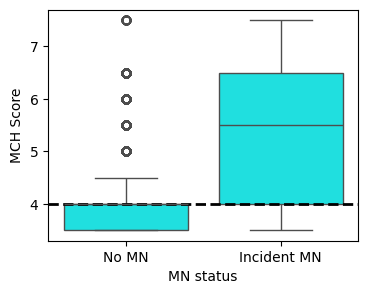

In [14]:
# Violin plots for CH_score vs MN
from scipy import stats

dist1=df_sel[df_sel['MN']==0]['CH_score']
dist2=df_sel[df_sel['MN']==1]['CH_score']

# Compute point-biserial correlation
r_pb, p_value = stats.pointbiserialr(df_sel['CH_score'], df_sel['MN'])

# Print results
print(f"Point-Biserial Correlation: {r_pb:.4f}")
print(f"P-value: {p_value:.4e}")
plt.figure(figsize=(4, 3))
#sns.boxplot(x=df_EDA['MN'], y=df_EDA['CH_score'])
sns.boxplot(x=df_sel['MN'], y=df_sel['CH_score'], color='cyan')
plt.axhline(y=4, color='black', linestyle='--', linewidth=2)
plt.xticks([0, 1], ['No MN', 'Incident MN'])
plt.xlabel('MN status')
plt.ylabel('MCH Score')
plt.savefig('figures/MCHvsMN_training.png',dpi=300,bbox_inches='tight')
plt.savefig("figures/MCHvsMN_training.svg", bbox_inches='tight')
plt.savefig("figures/MCHvsMN_training.pdf", bbox_inches='tight')

groups = df_sel['MN'].unique()

for group in groups:
    group_data = df_sel[df_sel['MN'] == group]['CH_score']
    q1 = np.percentile(group_data, 25)
    q2= np.percentile(group_data, 50)
    q3 = np.percentile(group_data, 75)
    iqr = q3 - q1
    print(f"Group: {group}, Q1: {q1:.2f},Q2: {q2:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}")    

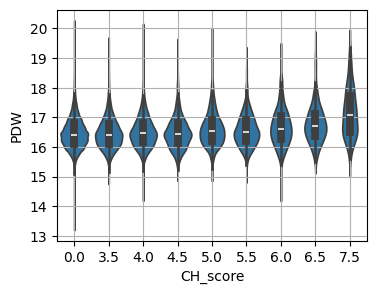

In [15]:
# Violing plots of CH_score for age and other covariates

plt.figure(figsize=(4, 3))
sns.violinplot(x=preprocessed_df['CH_score'], y=preprocessed_df['PDW'])
plt.grid()
#plt.ylim(70,120)

In [15]:
print(len(df_gene.loc[(df_gene['CH_score']==0)]),len(df_gene.loc[(df_gene['CH_score']==0)&(df_gene['MN']==1)]))
print(len(df_gene.loc[(df_gene['CH_score']>0)&(df_gene['CH_score']<=4)]),len(df_gene.loc[(df_gene['CH_score']>0)&(df_gene['CH_score']<=4)&(df_gene['MN']==1)]))
print(len(df_gene.loc[(df_gene['CH_score']>4)&(df_gene['CH_score']<=5.5)]),len(df_gene.loc[(df_gene['CH_score']>4)&(df_gene['CH_score']<=5.5)&(df_gene['MN']==1)]))
print(len(df_gene.loc[(df_gene['CH_score']>5.5)]),len(df_gene.loc[(df_gene['CH_score']>5.5)&(df_gene['MN']==1)]))

346270 892
17820 131
4331 120
839 174


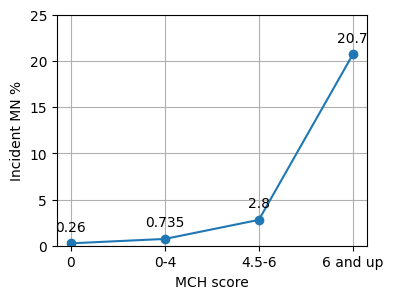

In [19]:
score=['0','0-4','4.5-6','6 and up']
x=[0,1,2,3]
values=[0.26,0.735,2.8,20.7]
plt.figure(figsize=(4,3))
plt.plot(x,values,'-o')
plt.xticks(ticks=x, labels=score)
# Add value labels above points
for xi, yi in zip(x, values):
    plt.text(xi, yi+0.05*max(values), f"{yi}", ha='center', va='bottom')
plt.grid()
plt.xlabel('MCH score')
plt.ylabel('Incident MN %')
plt.ylim(0,25)
plt.savefig('figures/MNfraction_training.png',dpi=300,bbox_inches='tight')
plt.savefig('figures/MNfraction_training.svg',bbox_inches='tight')
plt.savefig('figures/MNfraction_training.pdf',bbox_inches='tight')

### 2.2 EDA on CHRS ###

In [20]:
df_gene['CHRS'].value_counts()

CHRS
0.0     346270
8.0       7402
7.5       6694
8.5       3002
9.0       2065
9.5       1846
10.0       820
10.5       501
11.0       285
11.5       118
12.0       107
12.5        62
13.0        37
13.5        32
14.0        14
14.5         3
15.5         1
15.0         1
Name: count, dtype: int64

Text(0, 0.5, 'Counts')

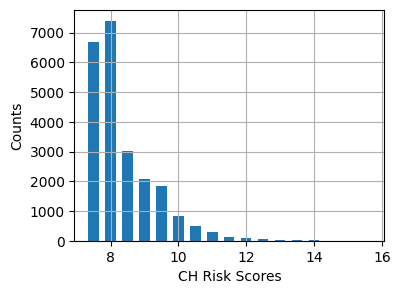

In [21]:
df_sel=df_gene.loc[df_gene['CHRS']>0]
value_counts=df_sel['CHRS'].value_counts()
values=value_counts.index.tolist()
counts=value_counts.values.tolist()
plt.figure(figsize=(4,3))
plt.bar(values,counts,width=0.3)
plt.grid()
plt.xlabel("CH Risk Scores")
plt.ylabel("Counts")

Point-Biserial Correlation: 0.2842
P-value: 0.0000e+00
Group: 0, Q1: 7.50,Q2: 8.00, Q3: 8.50, IQR: 1.00
Group: 1, Q1: 9.00,Q2: 10.00, Q3: 12.00, IQR: 3.00


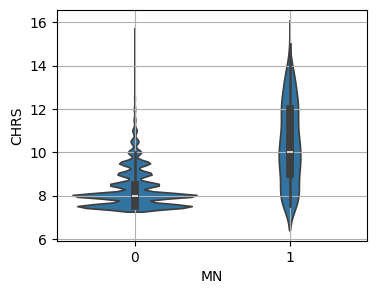

In [22]:
# Violin plots for CHRS vs MN
from scipy import stats

dist1=df_sel[df_sel['MN']==0]['CHRS']
dist2=df_sel[df_sel['MN']==1]['CHRS']

# Compute point-biserial correlation
r_pb, p_value = stats.pointbiserialr(df_sel['CHRS'], df_sel['MN'])

# Print results
print(f"Point-Biserial Correlation: {r_pb:.4f}")
print(f"P-value: {p_value:.4e}")
plt.figure(figsize=(4, 3))
#sns.boxplot(x=df_EDA['MN'], y=df_EDA['CH_score'])
sns.violinplot(x=df_sel['MN'], y=df_sel['CHRS'])

plt.grid()

groups = df_sel['MN'].unique()

for group in groups:
    group_data = df_sel[df_sel['MN'] == group]['CHRS']
    q1 = np.percentile(group_data, 25)
    q2= np.percentile(group_data, 50)
    q3 = np.percentile(group_data, 75)
    iqr = q3 - q1
    print(f"Group: {group}, Q1: {q1:.2f},Q2: {q2:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}")

In [23]:
# How many people with varying risks get MN

print(len(df_gene.loc[(df_gene['CHRS']==0)]),len(df_gene.loc[(df_gene['CHRS']==0)&(df_gene['MN']==1)]))
print(len(df_gene.loc[(df_gene['CHRS']>0)&(df_gene['CHRS']<10)]),len(df_gene.loc[(df_gene['CHRS']>0)&(df_gene['CHRS']<10)&(df_gene['MN']==1)]))
print(len(df_gene.loc[(df_gene['CHRS']>=10)&(df_gene['CHRS']<12.5)]),len(df_gene.loc[(df_gene['CHRS']>=10)&(df_gene['CHRS']<12.5)&(df_gene['MN']==1)]))
print(len(df_gene.loc[(df_gene['CHRS']>=12.5)]),len(df_gene.loc[(df_gene['CHRS']>=12.5)&(df_gene['MN']==1)]))

346270 892
21009 175
1831 169
150 81


Text(0, 0.5, 'Incident MN %')

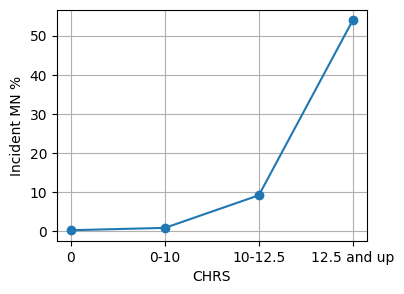

In [22]:
score=['0','0-10','10-12.5','12.5 and up']
x=[0,1,2,3]
values=[0.26,0.86,9.2,53.95]
plt.figure(figsize=(4,3))
plt.plot(x,values,'-o')
plt.xticks(ticks=x, labels=score)
plt.grid()
plt.xlabel('CHRS')
plt.ylabel('Incident MN %')

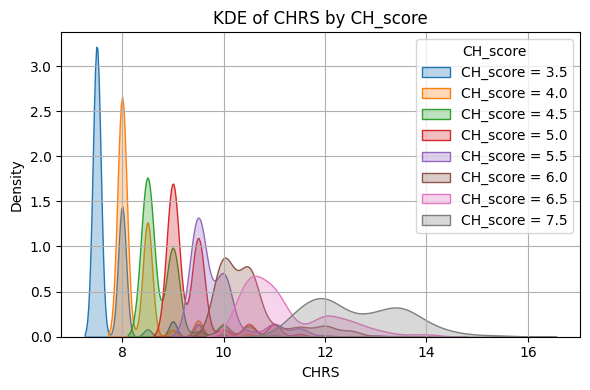

In [23]:
# --- choose which column we plot, and which column defines the groups ---
x_col      = 'CHRS'       # distribution you want on the x‑axis
group_col  = 'CH_score'   # defines the groups / separate curves

# --- find the groups we’ll iterate over ---
groups = sorted(df_sel[group_col].dropna().unique())   # list of distinct CH_score values

plt.figure(figsize=(6,4))

for g in groups:
    subset = df_sel[df_sel[group_col] == g][x_col].dropna()
    if len(subset) < 2:               # too few points → skip, KDE can’t be estimated
        continue
    sns.kdeplot(subset,
                fill=True, alpha=0.3,
                label=f'{group_col} = {g}')

plt.xlabel(x_col)
plt.ylabel('Density')
plt.title(f'KDE of {x_col} by {group_col}')
plt.grid(True)
plt.legend(title=group_col, loc='upper right')
plt.tight_layout()
plt.show()

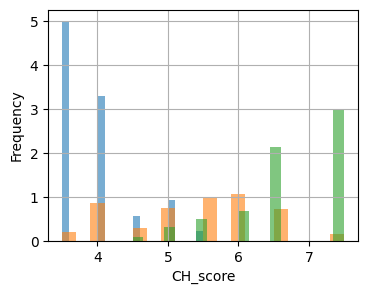

In [25]:
CHRS0=df_gene.loc[df_gene['CHRS']==0]['CH_score']
CHRS1=df_gene.loc[(df_gene['CHRS']>0)&(df_gene['CHRS']<10)]['CH_score']
CHRS2=df_gene.loc[(df_gene['CHRS']>=10)&(df_gene['CHRS']<12.5)]['CH_score']
CHRS3=df_gene.loc[df_gene['CHRS']>12]['CH_score']

plt.figure(figsize=(4, 3))
#plt.hist(CHRS0, bins=20, density=True, alpha=0.6, label='CHRS = 0')
plt.hist(CHRS1, bins=20, density=True,alpha=0.6, label='0 < CHRS < 10')
plt.hist(CHRS2, bins=20, density=True,alpha=0.6, label='10 ≤ CHRS < 12.5')
plt.hist(CHRS3, bins=20, density=True,alpha=0.6, label='CHRS > 12')
plt.xlabel('CH_score')
plt.ylabel('Frequency')
plt.grid()

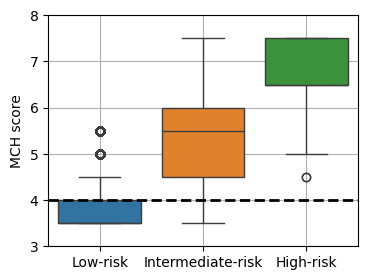

In [26]:
data = [CHRS1.values, CHRS2.values, CHRS3.values]
labels = ['Low-risk', 'Intermediate-risk', 'High-risk']

plt.figure(figsize=(4, 3))
sns.boxplot(data=data)
plt.axhline(y=4, color='black', linestyle='--', linewidth=2)
plt.xticks(ticks=range(3), labels=labels)
plt.ylabel('MCH score')
plt.ylim(3,8)
plt.grid()
plt.savefig('figures/MCHvsCHRS_training.png',dpi=300,bbox_inches='tight')
plt.savefig('figures/MCHvsCHRS_training.svg',bbox_inches='tight')
plt.savefig('figures/MCHvsCHRS_training.pdf',bbox_inches='tight')

In [26]:
df_sel2=df_gene[df_gene['CHRS']>10]
print(len(df_sel2), df_sel2['CH_score'].min())

1161 3.5


In [27]:
preprocessed_df.loc[(preprocessed_df['CHRS']>=10)&(preprocessed_df['CH_score']<=4)][['RDW','platelet','RBC','MCV','age','neutrophil']]

,RDW,platelet,RBC,MCV,age,neutrophil
440,19.12,337.1,5.045,83.41,65.250000,6.01
710,16.11,300.7,4.405,80.66,66.750000,6.14
2309,17.00,333.0,3.600,105.10,56.583333,7.80
3949,20.40,323.0,3.370,66.50,46.083333,3.70
4254,15.42,132.2,4.269,97.15,66.000000,3.42
...,...,...,...,...,...,...
458923,15.00,177.3,4.699,94.68,66.333333,6.10
459678,17.30,417.0,4.380,80.40,56.583333,4.10
459993,12.30,217.0,3.770,100.40,65.083333,3.80
460946,15.00,296.0,3.670,92.00,51.750000,3.80


* 484 participants have abnormal blood counts, and/or are above 65, leading to a CHRS of >=10 despite no molecular signatures of high risk CH. These participants will be further screened anyways.

### 2.3 Comparison of cohorts with and without incident MN ###

In [33]:
# select the cohort
df_gene=training_df[['gene1','gene2','gene3','VAF1','VAF2','VAF3','sex','CH_score','age','MN','CHRS']]

In [34]:
df_gene['MN'].value_counts()

MN
0    367943
1      1317
Name: count, dtype: int64

<Figure size 400x300 with 0 Axes>

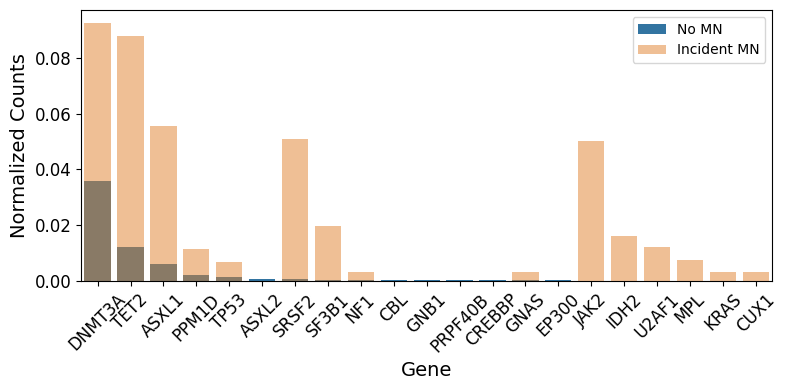

In [35]:
df_EDA1=df_gene[df_gene['MN']==0].copy()
df_EDA2=df_gene[df_gene['MN']==1].copy()
plt.figure(figsize=(4,3))

## driver genes: the 10 most commonly occuring mutations
mutations1=pd.concat([df_EDA1['gene1'],df_EDA1['gene2'],df_EDA1['gene3']])
mutations2=pd.concat([df_EDA2['gene1'],df_EDA2['gene2'],df_EDA2['gene3']])
counts1=mutations1.value_counts().head(15)
counts2=mutations2.value_counts().head(15)

# Plot the bar plot
plt.figure(figsize=(8, 4))
sns.barplot(x=counts1.index, y=counts1.values/len(df_EDA1),label='No MN')
sns.barplot(x=counts2.index, y=counts2.values/len(df_EDA2),alpha=0.5,label='Incident MN')
#plt.title('Top Mutations by count', fontsize=16)
plt.xlabel('Gene', fontsize=14)
plt.ylabel('Normalized Counts', fontsize=14)
plt.legend(loc='best')
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig("figures/mutation_counts_train.png", dpi=300, bbox_inches='tight')

31
341
5457


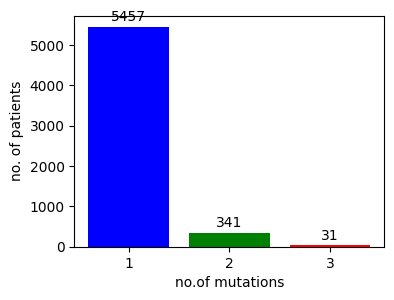

In [31]:

# Number of patients with 1,2,3 genes mutated
mut_3 = df_EDA1[['gene1', 'gene2', 'gene3']].notna().all(axis=1).sum()
print(mut_3)
mut_2 = (df_EDA1[['gene1', 'gene2', 'gene3']].notna().sum(axis=1)== 2).sum()
print(mut_2)
mut_1 = (df_EDA1[['gene1', 'gene2', 'gene3']].notna().sum(axis=1)== 1).sum()
print(mut_1)
'''
# Number of patients with 1,2,3 genes mutated
mut_3 = df_EDA2[['gene1', 'gene2', 'gene3']].notna().all(axis=1).sum()
print(mut_3)
mut_2 = (df_EDA2[['gene1', 'gene2', 'gene3']].notna().sum(axis=1)== 2).sum()
print(mut_2)
mut_1 = (df_EDA2[['gene1', 'gene2', 'gene3']].notna().sum(axis=1)== 1).sum()
print(mut_1)
'''
plt.figure(figsize=(4, 3))
values=[mut_3,mut_2,mut_1]
labels=[3,2,1]
colors=['red','green','blue']
bars = plt.bar(labels, values, color=colors)
plt.bar_label(bars, padding=2, fmt='%d')
plt.xlabel('no.of mutations')
plt.ylabel('no. of patients')
plt.xticks([1,2,3]);

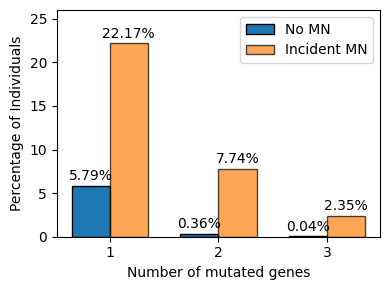

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# ---------- Helper: count # of mutated genes per patient ----------
def mutation_counts(df, gene_cols):
    n_mut = df[gene_cols].notna().sum(axis=1)
    return {1: (n_mut == 1).sum(),
            2: (n_mut == 2).sum(),
            3: (n_mut == 3).sum()}

gene_cols = ['gene1', 'gene2', 'gene3']

eda1_counts = mutation_counts(df_EDA1, gene_cols)
eda2_counts = mutation_counts(df_EDA2, gene_cols)

# ----- Convert to percentages (divide by cohort size) -----
n_eda1 = len(df_EDA1)          # total patients in EDA1
n_eda2 = len(df_EDA2)          # total patients in EDA2
eda1_pct = {k: v / n_eda1 * 100 for k, v in eda1_counts.items()}
eda2_pct = {k: v / n_eda2 * 100 for k, v in eda2_counts.items()}

# ---------- Plot ----------
labels    = np.array([1, 2, 3])
eda1_vals = [eda1_pct[i] for i in labels]
eda2_vals = [eda2_pct[i] for i in labels]

bar_width = 0.35
x         = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(4,3))

ax.bar(x - bar_width/2, eda1_vals, width=bar_width,
       label='No MN', edgecolor='black')
ax.bar(x + bar_width/2, eda2_vals, width=bar_width,
       label='Incident MN', edgecolor='black', alpha=0.7)

ax.set_xlabel('Number of mutated genes')
ax.set_ylabel('Percentage of Individuals')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0,26)
ax.legend(loc='upper right')

# annotate bars with percentage labels
for bars in ax.containers:
    ax.bar_label(bars, padding=2, fmt='%.2f%%')

plt.tight_layout()
plt.savefig("figures/mut_num_train.png",dpi=300, bbox_inches='tight')

4.011529619805482
5.367977528089888


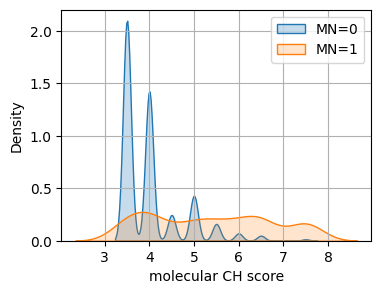

In [33]:
# KDE plots of molecular CH score for the MN and no-MN cohorts, only for patients with presence of CH

plt.figure(figsize=(4,3))
print(df_sel[df_sel['MN']==0]['CH_score'].mean())
print(df_sel[df_sel['MN']==1]['CH_score'].mean())
sns.kdeplot(df_sel[df_sel['MN']==0]['CH_score'],fill=True,label='MN=0');
sns.kdeplot(df_sel[df_sel['MN']==1]['CH_score'],fill=True,alpha=0.2,label='MN=1');
plt.legend()
plt.xlabel('molecular CH score')
plt.grid()
#plt.xlim(2.5,7.5)
#plt.ylim(0,0.1)

8.322740937223696
10.364232209737828


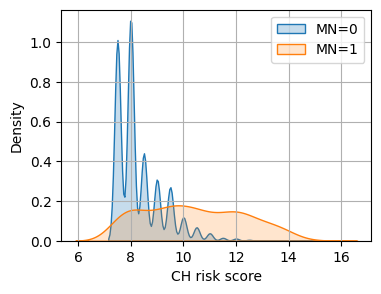

In [34]:
# KDE plots of CHRS for the MN and no-MN cohorts, only for patients with presence of CH

plt.figure(figsize=(4,3))
print(df_sel[df_sel['MN']==0]['CHRS'].mean())
print(df_sel[df_sel['MN']==1]['CHRS'].mean())
sns.kdeplot(df_sel[df_sel['MN']==0]['CHRS'],fill=True,label='MN=0');
sns.kdeplot(df_sel[df_sel['MN']==1]['CHRS'],fill=True,alpha=0.2,label='MN=1');
plt.legend()
plt.xlabel('CH risk score')
plt.grid()

## 3. Blood Count Paramters ##

In [32]:
columns_to_drop=['Broad_ID','gene1','gene2','gene3','VAF1','VAF2','VAF3','sex','CH_score','eid','age',
                 'year_of_assessment','year_MN','MN_type','MN','CHRS']
df_blood=preprocessed_df.drop(columns=columns_to_drop)
df_blood.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 461576 entries, 0 to 461575
Data columns (total 23 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   WBC           461576 non-null  float64
 1   RBC           461576 non-null  float64
 2   Hbconc        461576 non-null  float64
 3   haematocrit   461576 non-null  float64
 4   MCV           461576 non-null  float64
 5   MCHb          461576 non-null  float64
 6   MCHbconc      461576 non-null  float64
 7   RDW           461576 non-null  float64
 8   platelet      461576 non-null  float64
 9   plateletcrit  461576 non-null  float64
 10  MPV           461576 non-null  float64
 11  PDW           461576 non-null  float64
 12  lymphocyte    461576 non-null  float64
 13  monocyte      461576 non-null  float64
 14  neutrophil    461576 non-null  float64
 15  eosinophil    461576 non-null  float64
 16  basophil      461576 non-null  float64
 17  nucRBC        461576 non-null  float64
 18  reti

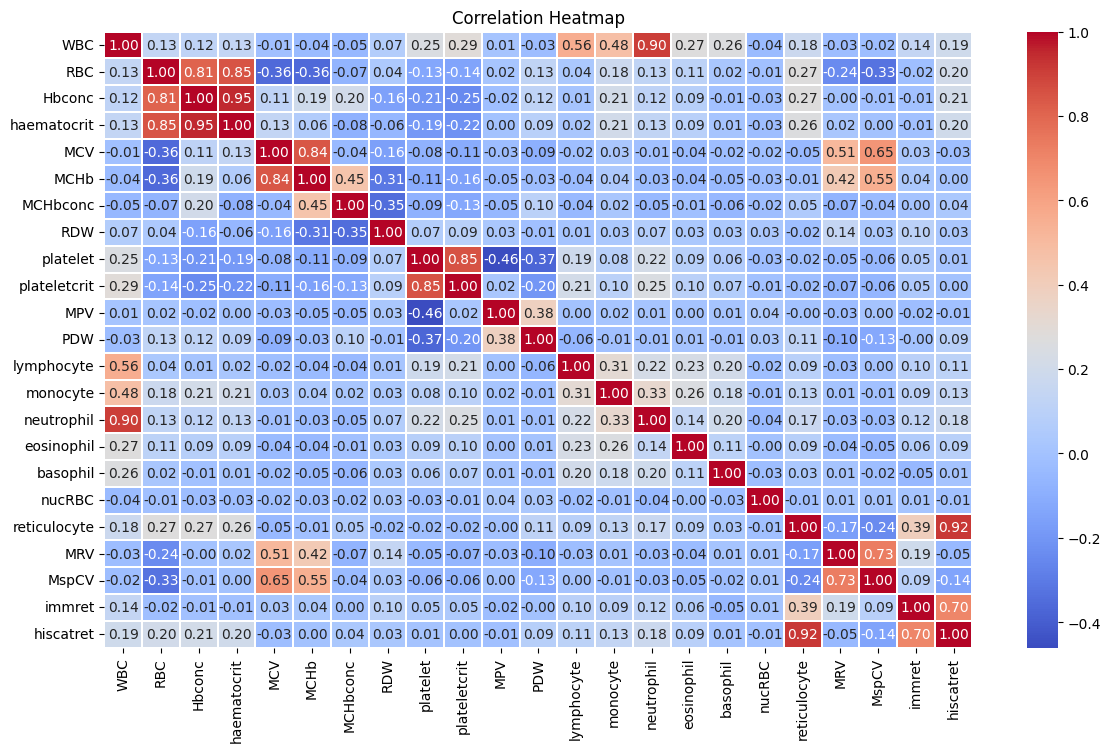

In [33]:
correlation_matrix=df_blood.corr(method='spearman')

# Plot the correlation heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.1)
plt.title('Correlation Heatmap')
plt.savefig("figures/CBC_correlation.png",dpi=300,bbox_inches='tight')
plt.savefig("figures/CBC_correlation.pdf",bbox_inches='tight')
plt.savefig("figures/CBC_correlation.svg",bbox_inches='tight')

### 2.1 PDW and a cutoff of giant platelet ###

Mean: 16.49
Median: 16.42
Standard Deviation: 0.52


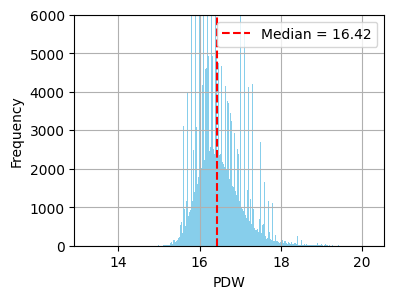

In [34]:
# Compute statistics
mean_val = preprocessed_df['PDW'].mean()
median_val = preprocessed_df['PDW'].median()
std_val = preprocessed_df['PDW'].std()

# Print stats
print(f"Mean: {mean_val:.2f}")
print(f"Median: {median_val:.2f}")
print(f"Standard Deviation: {std_val:.2f}")

# Plot histogram with median line
plt.figure(figsize=(4, 3))
plt.hist(preprocessed_df['PDW'], bins=500, color='skyblue')
plt.axvline(median_val, color='red', linestyle='--', label=f'Median = {median_val:.2f}')
plt.xlabel('PDW')
plt.ylabel('Frequency')
plt.grid(True)
plt.ylim(0,6000)
plt.legend()

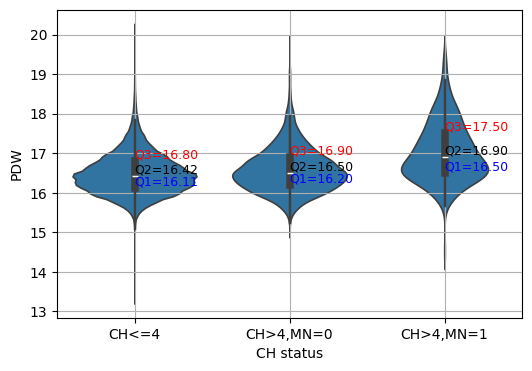

In [35]:
df_LR=preprocessed_df[preprocessed_df['CH_score']<=4][['PDW']]
df_MR=preprocessed_df[(preprocessed_df['CH_score']>4)&(preprocessed_df['MN']==0)][['PDW']]
df_HR=preprocessed_df[(preprocessed_df['CH_score']>4)&(preprocessed_df['MN']==1)][['PDW']]

# Prepare long-form DataFrame for violin plot
df_violin = pd.concat([
    pd.DataFrame({'PDW': df_LR['PDW'].values, 'CH status': 'CH<=4'}),
    pd.DataFrame({'PDW': df_MR['PDW'].values, 'CH status': 'CH>4,MN=0'}),
    pd.DataFrame({'PDW': df_HR['PDW'].values, 'CH status': 'CH>4,MN=1'})
])

# Plot violin
plt.figure(figsize=(6, 4))
sns.violinplot(x='CH status', y='PDW', data=df_violin, inner='box', linewidth=1.2)

# Annotate quartiles manually
for i, label in enumerate(['CH<=4', 'CH>4,MN=0', 'CH>4,MN=1']):
    group = df_violin[df_violin['CH status'] == label]['PDW'].dropna()
    q1, q2, q3 = np.percentile(group, [25, 50, 75])
    plt.text(i, q1, f'Q1={q1:.2f}', ha='left', va='bottom', fontsize=9, color='blue')
    plt.text(i, q2, f'Q2={q2:.2f}', ha='left', va='bottom', fontsize=9, color='black')
    plt.text(i, q3, f'Q3={q3:.2f}', ha='left', va='bottom', fontsize=9, color='red')

plt.ylabel('PDW')
plt.grid()

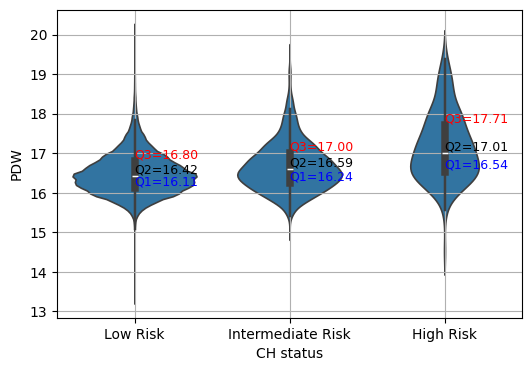

In [42]:
df_LR=preprocessed_df[preprocessed_df['CHRS']<10][['PDW']]
df_MR=preprocessed_df[(preprocessed_df['CHRS']>=10)&(preprocessed_df['CHRS']<=12)][['PDW']]
df_HR=preprocessed_df[(preprocessed_df['CHRS']>12)][['PDW']]

# Prepare long-form DataFrame for violin plot
df_violin = pd.concat([
    pd.DataFrame({'PDW': df_LR['PDW'].values, 'CH status': 'Low Risk'}),
    pd.DataFrame({'PDW': df_MR['PDW'].values, 'CH status': 'Intermediate Risk'}),
    pd.DataFrame({'PDW': df_HR['PDW'].values, 'CH status': 'High Risk'})
])

# Plot violin
plt.figure(figsize=(6, 4))
sns.violinplot(x='CH status', y='PDW', data=df_violin, inner='box', linewidth=1.2)

# Annotate quartiles manually
for i, label in enumerate(['Low Risk', 'Intermediate Risk', 'High Risk']):
    group = df_violin[df_violin['CH status'] == label]['PDW'].dropna()
    q1, q2, q3 = np.percentile(group, [25, 50, 75])
    plt.text(i, q1, f'Q1={q1:.2f}', ha='left', va='bottom', fontsize=9, color='blue')
    plt.text(i, q2, f'Q2={q2:.2f}', ha='left', va='bottom', fontsize=9, color='black')
    plt.text(i, q3, f'Q3={q3:.2f}', ha='left', va='bottom', fontsize=9, color='red')

plt.ylabel('PDW')
plt.grid()

## Ethnicity distribution ##

In [5]:
df_race=pd.read_csv('/Users/riyanandi/Desktop/UKBB/ukb45304.csv',usecols=['eid','21000-0.0'])
df_race.head()

,eid,21000-0.0
0,1000010,1002.0
1,1000028,1001.0
2,1000034,1001.0
3,1000045,1001.0
4,1000052,1001.0


In [6]:
eid_preprocessed=preprocessed_df['eid']
df_sel_race=df_race[df_race['eid'].isin(eid_preprocessed)]
len(df_sel_race)

461576

In [29]:
white_code=[1001.0,1002.0,1003.0]
mixed_code=[2001.0,2002.0,2003.0,2004.0]
asian_code=[3001.0,3002.0,3003.0,3004.0]
black_code=[4001.0,4002.0,4003.0]
chinese_code=[5.0]
other=[6.0]

white=df_sel_race.loc[df_sel_race['21000-0.0'].isin(white_code)]
print("white:", len(white), "percentage:", len(white)*100/len(preprocessed_df))
mixed=df_sel_race.loc[df_sel_race['21000-0.0'].isin(mixed_code)]
print("mixed:", len(mixed), "percentage:", len(mixed)*100/len(preprocessed_df))
asian=df_sel_race.loc[df_sel_race['21000-0.0'].isin(asian_code)]
print("asian:", len(asian), "percentage:", len(asian)*100/len(preprocessed_df))
black=df_sel_race.loc[df_sel_race['21000-0.0'].isin(black_code)]
print("black:", len(black), "percentage:", len(black)*100/len(preprocessed_df))
chinese=df_sel_race.loc[df_sel_race['21000-0.0'].isin(chinese_code)]
print("chinese:", len(chinese), "percentage:", len(chinese)*100/len(preprocessed_df))

white: 434911 percentage: 94.22305319167374
mixed: 2644 percentage: 0.5728200773003795
asian: 8752 percentage: 1.8961124495207724
black: 7009 percentage: 1.518493162556112
chinese: 1422 percentage: 0.30807494323795
